# Exploratory Analysis Markdown

Date: 19/06/2026  
Author: Bryce Lim

This markdownfile serves as a workspace to understand the data structure of the provided files and potential ideas for analysis and visualisations

**Imports and Loading**

In [1]:
# Import relevant packages and dependencies
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dash


In [2]:
# Get the working directory
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\bryce\Python Projects\COFINFAD-Project\notebooks


In [3]:
# Load data as pandas dataframes
customer_df = pd.read_csv("../data/customer_data.csv")
transactions_df = pd.read_csv("../data/transactions_data.csv")

In [4]:
# Quick overview of each dataset, uncomment as needed
# print("Customer Data Info:")
# print(customer_df.info())
# print(customer_df.head())
print(f"Missing values:\n{customer_df.isnull().sum()}")

# print("\nTransaction Data Info:")
# print(transactions_df.info())
# print(transactions_df.head())
print(f"Missing values:\n{transactions_df.isnull().sum()}")

Missing values:
customer_id                       0
age                               0
gender                            0
location                          0
income_bracket                    0
occupation                        0
education_level                   0
marital_status                    0
household_size                    0
acquisition_channel               0
customer_segment                  0
savings_account                   0
credit_card                       0
personal_loan                     0
investment_account                0
insurance_product                 0
active_products                   0
app_logins_frequency              0
feature_usage_diversity           0
bill_payment_user                 0
auto_savings_enabled              0
credit_utilization_ratio      18263
international_transactions        0
failed_transactions               0
tx_count                          0
avg_tx_value                      0
total_tx_volume                   0
first_tx    

**Check Missing Values**

In [5]:
# Check the columns that have missing data, are they expected?
customer_cols_with_nan = customer_df.columns[customer_df.isnull().any()]
print("Columns with missing data:", list(customer_cols_with_nan))

transactions_cols_with_nan = transactions_df.columns[transactions_df.isnull().any()]
print("Columns with missing data:", list(transactions_cols_with_nan))


Columns with missing data: ['credit_utilization_ratio', 'feature_requests', 'complaint_topics']
Columns with missing data: []


Nothing out of the ordinary for the missing data in customer dataframe

**Explore the data**

In [ ]:
# Check the Customer df shape and types
print(customer_df.shape)
# print(customer_df.dtypes)

# Check the transactions df shape and types
print(transactions_df.shape)
print(transactions_df.dtypes)

(48723, 54)
(3159157, 4)
customer_id    int64
date             str
amount         int64
type             str
dtype: object


: 

Average transaction value for Gold customers: 3539671.352663548
Total transaction volume for Gold customers: 240954406.3998358
Average transaction value for Bronze customers: 3565174.845802079
Total transaction volume for Bronze customers: 211993153.11550775


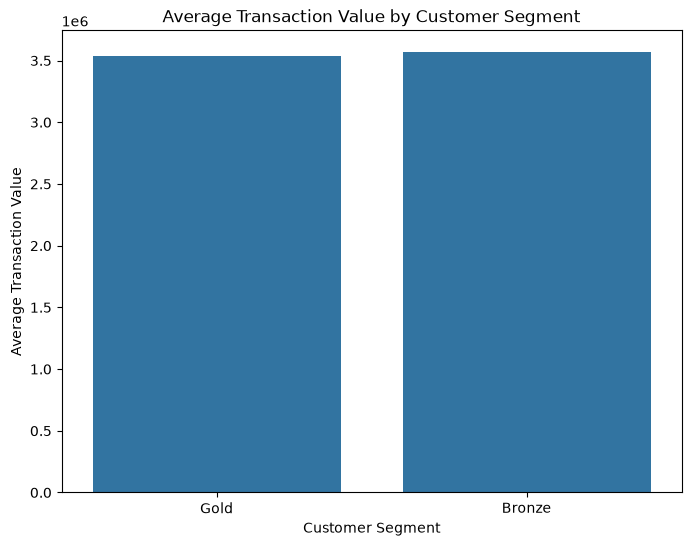

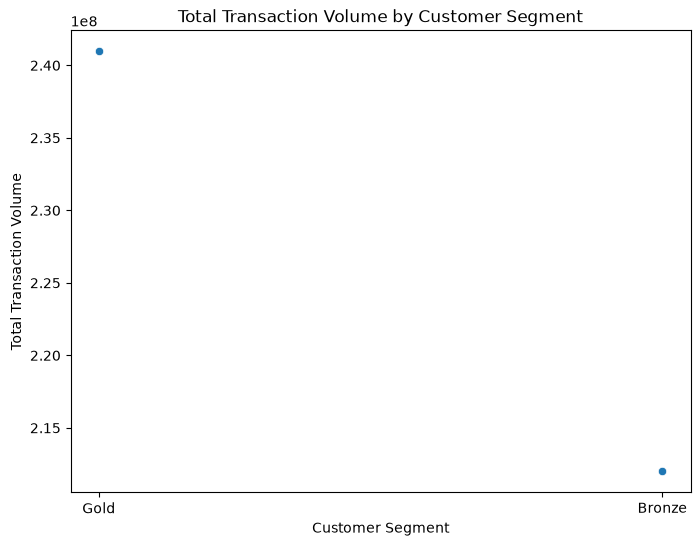

In [6]:
# Filter data to include only Gold customers
gold_customers = customer_df[customer_df['clv_segment'] == 'Gold']

# Calculate average transaction value and total transaction volume for each customer
gold_transactions = gold_customers[['average_transaction_value', 'total_transaction_volume']]
gold_transactions_avg = gold_transactions.mean()
print(f"Average transaction value for Gold customers: {gold_transactions_avg['average_transaction_value']}")
print(f"Total transaction volume for Gold customers: {gold_transactions_avg['total_transaction_volume']}")

# Filter data to include only Bronze customers
bronze_customers = customer_df[customer_df['clv_segment'] == 'Bronze']

# Calculate average transaction value and total transaction volume for each customer
bronze_transactions = bronze_customers[['average_transaction_value', 'total_transaction_volume']]
bronze_transactions_avg = bronze_transactions.mean()
print(f"Average transaction value for Bronze customers: {bronze_transactions_avg['average_transaction_value']}")
print(f"Total transaction volume for Bronze customers: {bronze_transactions_avg['total_transaction_volume']}")

# Create a bar plot to compare average transaction values and total transaction volumes
plt.figure(figsize=(8, 6))
sns.barplot(x=['Gold', 'Bronze'], y=[gold_transactions_avg['average_transaction_value'], bronze_transactions_avg['average_transaction_value']])
plt.title('Average Transaction Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Transaction Value')
plt.show()

# Create a scatter plot to compare total transaction volumes
plt.figure(figsize=(8, 6))
sns.scatterplot(x=['Gold', 'Bronze'], y=[gold_transactions_avg['total_transaction_volume'], bronze_transactions_avg['total_transaction_volume']])
plt.title('Total Transaction Volume by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Transaction Volume')
plt.show()